In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import glob
import chardet

In [5]:
# 读取文件夹中所有文件画图
def together_plot(folder_path,row,col,n):
    # 输入要画的文件的所在路径folder_path,换的图是几行几列组成，row代码行，col代表列,n代表要画的子图数量
    # 比如要画的csv文件全部存在D：/country文件夹里面,共32个csv文件，且画的图是5行7列组成
    # 那么调用函数为together_plot("D:/country/",5,7,32)
    
    # 定义一个格式化函数，例如将数值除以1000000
    def custom_formatter(x, pos):
        return f"{x / 1000000}"
    def country_plot(data,data_name):
    
        # 计算每个年份的Value总和
        years_sum = data.groupby("Year Code")["Value"].sum()
        years_sum = pd.DataFrame(years_sum)
    
        # 画图并且设置坐标刻度
        plt.plot(years_sum.index, years_sum["Value"])
        plt.xticks([1960,1990,2020])
    
        # 设置纵坐标的格式化器
        plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    
        # 添加文字
        plt.text(0.5,0.85,data_name,ha="center",va="center",transform=plt.gca().transAxes,fontweight="bold")
        
    # 读取文件夹中所有文件画图
    csv_file = glob.glob(f"{folder_path}/*.csv")
    count = 0
    while count!=len(csv_file):
        subplot_count = 1
        plt.figure(figsize=(col*2,row*2))
        for i in range(count,min(count+min(n,col*row),len(csv_file))):
            with open(csv_file[i],"rb") as file:
                raw_data = file.read()
                encoding_file = chardet.detect(raw_data)["encoding"]
            if encoding_file != "utf-8":
                print("文件"+csv_file[i]+"编码不是utf-8，而是:"+encoding_file,"，请查看文件具体情况")
                continue
            data = pd.read_csv(csv_file[i])
            plt.subplot(row,col,subplot_count)
            # 用正则表达式提取出国家简写
            pattern = r"\((.*?)\)"
            matches = re.findall(pattern,csv_file[i])
            country_plot(data,matches[-1])
            plt.tick_params(axis="x",labelsize=8)
            plt.tick_params(axis="y",labelsize=8)
            subplot_count+=1
        count = min(count+min(n,col*row),len(csv_file))
    plt.tight_layout()
    plt.show()

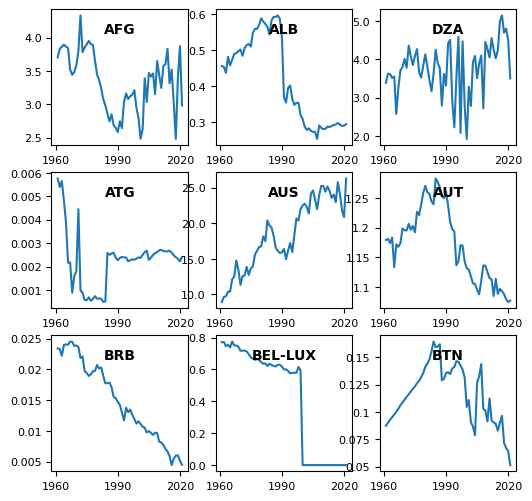

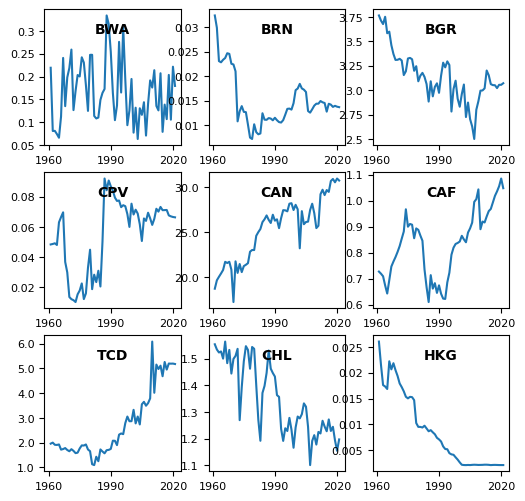

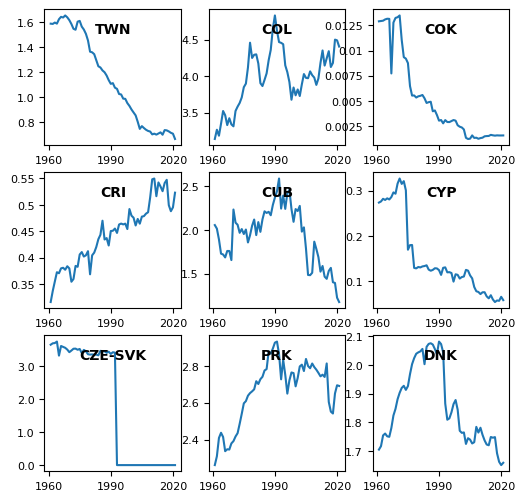

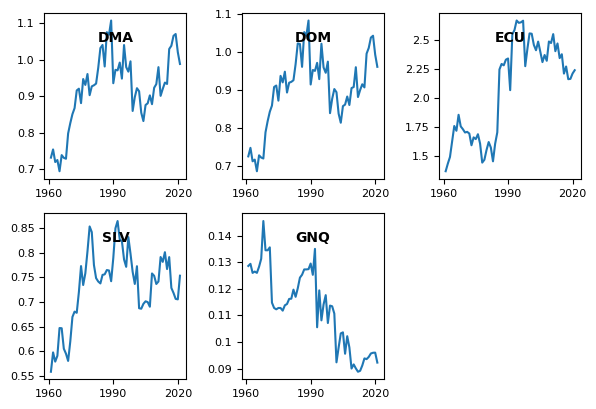

In [6]:
folder_path = "country/"
together_plot(folder_path,3,3,9)

In [1]:
# 读取文件夹中所有文件画图
def together_plot(folder_path,row,col,n):
    # 输入要画的文件的所在路径folder_path,换的图是几行几列组成，row代码行，col代表列,n代表要画的子图数量
    # 比如要画的csv文件全部存在D：/country文件夹里面,共32个csv文件，且画的图是5行7列组成
    # 那么调用函数为together_plot("D:/country/",5,7,32)
    
    # 定义一个格式化函数，例如将数值除以1000000
    def custom_formatter(x, pos):
        return f"{x / 1000000}"
    def country_plot(data,data_name):
    
        # 计算每个年份的Value总和
        years_sum = data.groupby("Year Code")["Value"].sum()
        years_sum = pd.DataFrame(years_sum)
    
        # 画图并且设置坐标刻度
        plt.plot(years_sum.index, years_sum["Value"])
        plt.xticks([1960,1990,2020])
    
        # 设置纵坐标的格式化器
        plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    
        # 添加文字
        plt.text(0.5,0.85,data_name,ha="center",va="center",transform=plt.gca().transAxes,fontweight="bold")
        
    # 读取文件夹中所有文件画图
    csv_file = glob.glob(f"{folder_path}/*.csv")
    count = 0
    while count!=len(csv_file):
        subplot_count = 1
        plt.figure(figsize=(col*2,row*2))
        for i in range(count,min(count+min(n,col*row),len(csv_file))):
            with open(csv_file[i],"rb") as file:
                raw_data = file.read()
                encoding_file = chardet.detect(raw_data)["encoding"]
            if encoding_file != "utf-8":
                print("文件"+csv_file[i]+"编码不是utf-8，而是:"+encoding_file,"，请查看文件具体情况")
                continue
            data = pd.read_csv(csv_file[i])
            plt.subplot(row,col,subplot_count)
            # 用正则表达式提取出国家简写
            pattern = r"\((.*?)\)"
            matches = re.findall(pattern,csv_file[i])
            country_plot(data,matches[-1])
            plt.tick_params(axis="x",labelsize=8)
            plt.tick_params(axis="y",labelsize=8)
            subplot_count+=1
        count = min(count+min(n,col*row),len(csv_file))
    plt.tight_layout()
    plt.show()